<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/Types_of_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('homeprices_banglore.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [3]:
from sklearn.preprocessing import MinMaxScaler
sx=MinMaxScaler()
sy=MinMaxScaler()

scaled_x=sx.fit_transform(df.drop('price',axis='columns'))
scaled_y=sy.fit_transform(df[['price']])


In [4]:
scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [5]:
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [6]:
def batch_gradient_descent(X,y_true,epochs,learning_rate=0.01):
  num_of_features=X.shape[1]
  w=np.ones(shape=(num_of_features))
  b=0
  total_samples=X.shape[0]

  cost_list=[]
  epoch_list=[]

  for i in range(epochs):
    y_predicted=np.dot(w,X.T)+b

    w_grad = -(2/total_samples)*(X.T.dot(y_true-y_predicted))
    b_grad = -(2/total_samples)*np.sum(y_true-y_predicted)


    w=w-learning_rate*w_grad
    b=b-learning_rate*b_grad

    cost=np.mean(np.square(y_true-y_predicted))

    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w,b,cost,cost_list,epoch_list

In [8]:
w,b,cost,cost_list,epoch_list=batch_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0],),500)
w,b,cost,cost_list,epoch_list

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105),
 [np.float64(0.2768777174681),
  np.float64(0.16573507027671064),
  np.float64(0.10212908135956808),
  np.float64(0.06564235879682481),
  np.float64(0.04463022365578522),
  np.float64(0.03245122421764872),
  np.float64(0.025317339083010492),
  np.float64(0.021067914076635823),
  np.float64(0.01847041893523527),
  np.float64(0.016821657535428185),
  np.float64(0.015720331469182485),
  np.float64(0.014937329116527901),
  np.float64(0.014341749105819087),
  np.float64(0.0138587099774241),
  np.float64(0.013445288028074867),
  np.float64(0.013076793952344979),
  np.float64(0.012738945874049962),
  np.float64(0.012423405193086517),
  np.float64(0.012125230310262438),
  np.float64(0.011841424159334757),
  np.float64(0.011570105565415722),
  np.float64(0.011310036391930275),
  np.float64(0.01106035160957391),
  np.float64(0.010820405104702651),
  np.float64(0.010589681505198633),
  np.floa

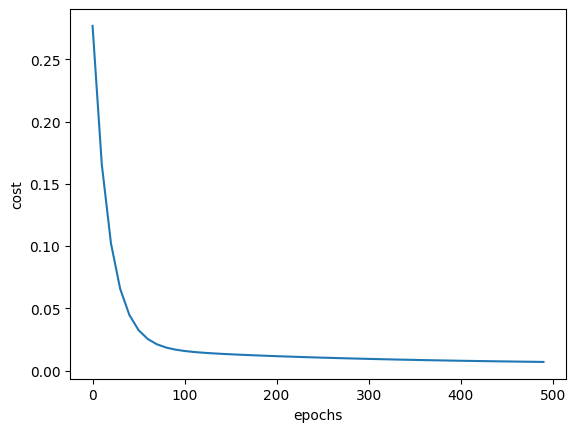

In [9]:
plt.xlabel('epochs')
plt.ylabel('cost')
plt.plot(epoch_list,cost_list)

#Stochastic  Gradient  Descent  Implementation

In [10]:
import random
def stochastic_gradient_descent(X,y_true,epochs,learning_rate=0.01):
  num_of_features=X.shape[1]
  w=np.ones(shape=(num_of_features))
  b=0
  total_samples=X.shape[0]

  cost_list=[]
  epoch_list=[]

  for i in range(epochs):

    random_index=random.randint(0,total_samples-1)
    sample_x=X[random_index]
    sample_y=y_true[random_index]


    y_predicted=np.dot(w,sample_x.T)+b

    w_grad = -(2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
    b_grad = -(2/total_samples)*np.sum(sample_y-y_predicted)


    w=w-learning_rate*w_grad
    b=b-learning_rate*b_grad

    cost=np.mean(np.square(sample_y-y_predicted))

    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w,b,cost,cost_list,epoch_list

In [12]:
w,b,cost,cost_list,epoch_list=stochastic_gradient_descent(scaled_x,scaled_y.reshape(scaled_y.shape[0],),500)
w,b,cost,cost_list,epoch_list

(array([0.91059771, 0.89296061]),
 np.float64(-0.1725395623749985),
 np.float64(0.00892612696045668),
 [np.float64(0.08174195018341542),
  np.float64(0.976119949720583),
  np.float64(0.07419439107519485),
  np.float64(0.4031692469368898),
  np.float64(0.38047841252383935),
  np.float64(0.09173550686699368),
  np.float64(0.44018597164240497),
  np.float64(0.058842374844066646),
  np.float64(0.8375875302798044),
  np.float64(0.16661982399271014),
  np.float64(0.16314582616543113),
  np.float64(0.22088480931755972),
  np.float64(0.03170603807465154),
  np.float64(0.31419470368084523),
  np.float64(0.028517766246030897),
  np.float64(0.2829721785919816),
  np.float64(0.3528599928581827),
  np.float64(0.03471922119364032),
  np.float64(0.7048639724517225),
  np.float64(0.035432274720754796),
  np.float64(0.020051800228484445),
  np.float64(0.1383175601734995),
  np.float64(0.03289022077593217),
  np.float64(0.009587630350231217),
  np.float64(0.03305862273990713),
  np.float64(0.12263901210

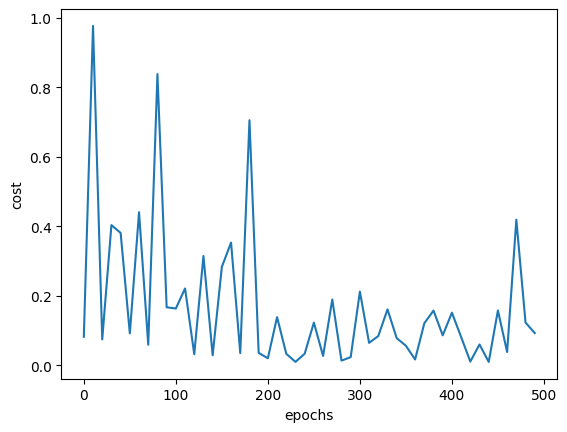

In [13]:
plt.xlabel('epochs')
plt.ylabel('cost')
plt.plot(epoch_list,cost_list)

#Let's implement Mini Batch Gradient Descent

In [14]:
def mini_batch_gradient(X,y_true,epochs,learning_rate=0.01):
  number_of_features=X.shape[1]
  w=np.ones(shape=(number_of_features))
  bias=0
  total_samples=X.shape[0]
  batch_size=int(total_samples/100)

  cost_list=[]
  epoch_list=[]

  for i in range(epochs):
    random_indices=np.random.permutation(total_samples)
    x_tmp=X[random_indices]
    y_tmp=y_true[random_indices]

    for j in range(0,total_samples,batch_size):
      xj=x_tmp[j:j+batch_size]
      yj = y_tmp[j:j+batch_size]

      y_predicted=np.dot(w,xj.T)+bias

      w_grad = -(2/batch_size)*(xj.T.dot(yj-y_predicted))
      b_grad = -(2/batch_size)*np.sum(yj-y_predicted)

      w=w-learning_rate*w_grad
      bias=bias-learning_rate*b_grad

      cost=np.mean(np.square(yj-y_predicted))

      if i%10==0:
        cost_list.append(cost)
        epoch_list.append(i)
  return w, b, cost, cost_list, epoch_list



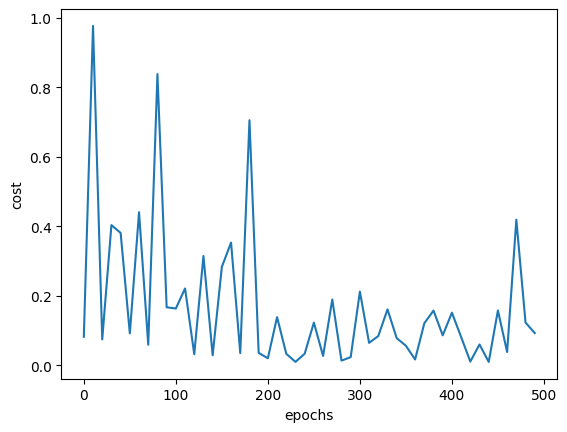

In [15]:
plt.xlabel('epochs')
plt.ylabel('cost')
plt.plot(epoch_list,cost_list)